# The Steepener Trade

## Data Imports

In [3]:
import pandas as pd

#DATE = '2023-06-30'
DATE = '2024-01-02'

FILE_DATA = f'../data/steepener_trade_{DATE}.xlsx'

info = pd.read_excel(FILE_DATA,sheet_name='info').set_index('KYTREASNO').T
clean = pd.read_excel(FILE_DATA,sheet_name='clean price').set_index('quote date')
dirty = pd.read_excel(FILE_DATA,sheet_name='dirty price').set_index('quote date')
duration = pd.read_excel(FILE_DATA,sheet_name='duration').set_index('quote date')

print("Dirty Prices:")
display(dirty)
print("Duration:")
display(duration)


Dirty Prices:


,207652,208147
quote date,,
2023-11-09,90.978261,99.000000
2023-11-10,90.940217,98.789062
2023-11-13,91.005774,98.882812
2023-11-14,91.397418,100.414062
2023-11-15,91.253906,99.742188
...,...,...
2025-05-23,97.904452,100.762021
2025-05-27,97.907937,101.224864
2025-05-28,97.913829,100.967561


Duration:


,207652,208147
quote date,,
2023-11-09,2.135193,8.173725
2023-11-10,2.132450,8.168483
2023-11-13,2.124233,8.160898
2023-11-14,2.121523,8.174992
2023-11-15,2.118771,8.164722
...,...,...
2025-05-23,0.607258,7.147798
2025-05-27,0.596299,7.140169
2025-05-28,0.593559,7.135270


### 1.1
- 50 million long in the 2 year bond

In [12]:
long_position = 50*(10**7)  # $50 million
interest_ratio = duration.loc['2023-11-09',:].loc[207652] * dirty.loc['2023-11-09',:].loc[207652] / (duration.loc['2023-11-09',:].loc[208147] * dirty.loc['2023-11-09',:].loc[208147])
short_dollar = long_position * interest_ratio
print(f"short_dollar: {short_dollar}")
two_year_bond = long_position / dirty.loc['2023-11-09',:].loc[207652]
print(f"two_year_bond: {two_year_bond}")
ten_year_bond = short_dollar / dirty.loc['2023-11-09',:].loc[208147]
print(f"ten_year_bond: {ten_year_bond}")

short_dollar: 120029954.81079713
two_year_bond: 5495818.399044205
ten_year_bond: 1212423.7859676478


### 1.2 Dynamic Hedge

Final P&L: 32123451.97 $


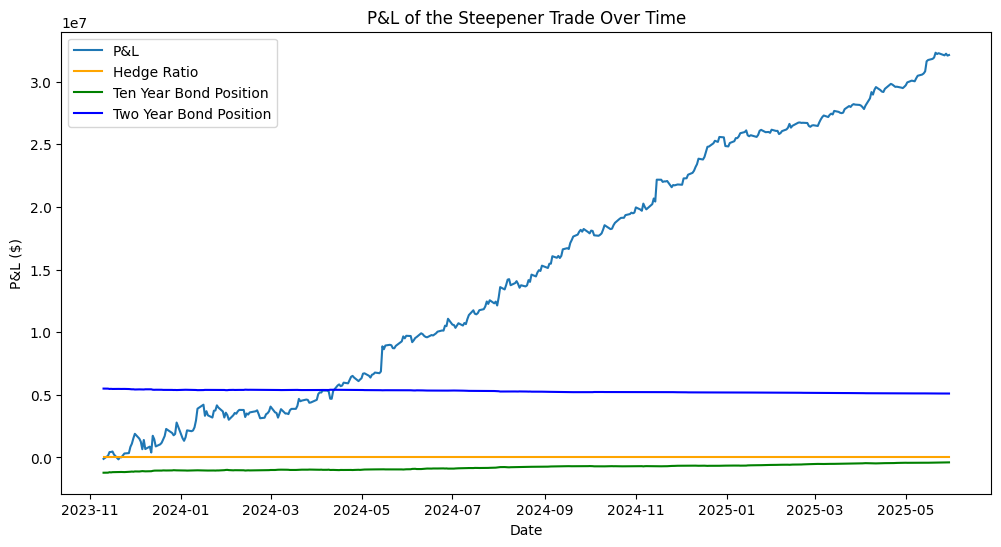

In [23]:
pnl = 0
pnl_list = []
hedge_ratio_list = []
ten_year_bond_list = []
two_year_bond_list = []

for i in range(len(dirty)):
    if i == 0:
        continue
    date = dirty.index[i]
    dirty_2y_prev = dirty.iloc[i-1,:].loc[207652]
    dirty_10y_prev = dirty.iloc[i-1,:].loc[208147]
    dirty_2y_curr = dirty.iloc[i,:].loc[207652]
    dirty_10y_curr = dirty.iloc[i,:].loc[208147]

    pnl += two_year_bond * (dirty_2y_curr - dirty_2y_prev) - ten_year_bond * (dirty_10y_curr - dirty_10y_prev)
    pnl_list.append((date, pnl))

    two_year_bond = long_position / dirty.iloc[i,:].loc[207652]
    interest_ratio = duration.iloc[i,:].loc[207652] * dirty.iloc[i,:].loc[207652] / (duration.iloc[i,:].loc[208147] * dirty.iloc[i,:].loc[208147])
    hedge_ratio_list.append((date, interest_ratio))
    short_dollar = long_position * interest_ratio
    ten_year_bond = short_dollar / dirty.iloc[i,:].loc[208147]
    ten_year_bond_list.append((date, ten_year_bond))
    two_year_bond_list.append((date, two_year_bond))


ten_year_bond_list = [(x[0], x[1]*-1) for x in ten_year_bond_list]

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot([x[0] for x in pnl_list], [x[1] for x in pnl_list], label='P&L')
plt.plot([x[0] for x in hedge_ratio_list], [x[1] for x in hedge_ratio_list], label='Hedge Ratio', color='orange')
plt.plot([x[0] for x in ten_year_bond_list], [x[1] for x in ten_year_bond_list], label='Ten Year Bond Position', color='green')
plt.plot([x[0] for x in two_year_bond_list], [x[1] for x in two_year_bond_list], label='Two Year Bond Position', color='blue')
plt.xlabel('Date')
plt.ylabel('P&L ($)')
plt.title('P&L of the Steepener Trade Over Time')
plt.legend()
print(f"Final P&L: {pnl:.2f} $")

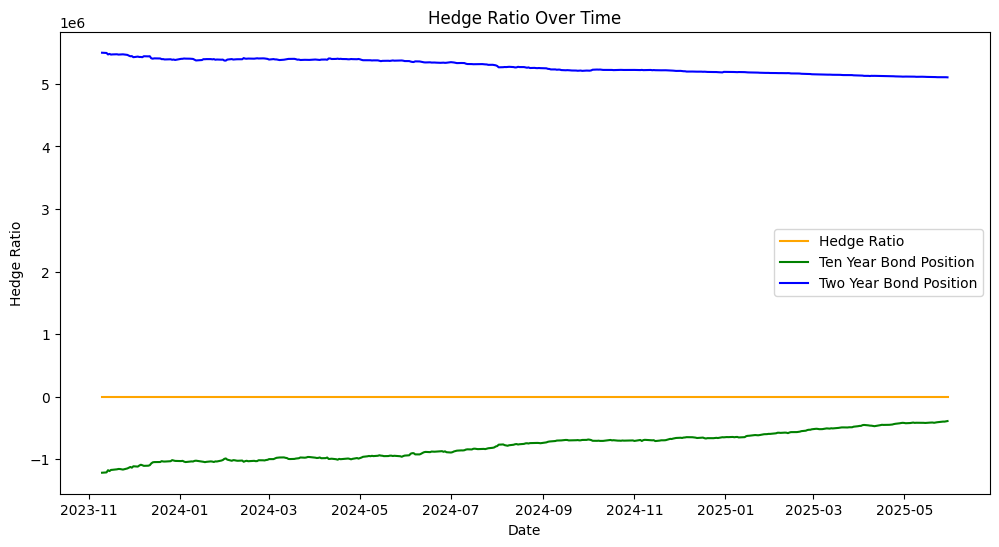

In [24]:
plt.figure(figsize=(12,6))
plt.plot([x[0] for x in hedge_ratio_list], [x[1] for x in hedge_ratio_list], label='Hedge Ratio', color='orange')
plt.plot([x[0] for x in ten_year_bond_list], [x[1] for x in ten_year_bond_list], label='Ten Year Bond Position', color='green')
plt.plot([x[0] for x in two_year_bond_list], [x[1] for x in two_year_bond_list], label='Two Year Bond Position', color='blue')
plt.xlabel('Date')
plt.ylabel('Hedge Ratio')
plt.title('Hedge Ratio Over Time')
plt.legend()